# The Multiple Regression Model

## Cholera outbreak

![John Snow](https://upload.wikimedia.org/wikipedia/commons/c/cc/John_Snow.jpg) [John Snow](https://en.wikipedia.org/wiki/John_Snow) was an English physicist famous for locating the source of the London cholera epidemic of 1854. At the time of the outbreak the germ theory of disease transmission was not yet developed and cholera was blamed on bad air. John Snow investigated the cases and concluded that the source of the outbreak is a water pump located on Broad Street. He was able to convince the city council to shut down the pump but people initially resisted his theory of water born transmission, because it seemed to be socially unacceptable.

![Cholera cases](http://blog.rtwilson.com/wp-content/uploads/2012/01/SnowMap_Points.png)

![Broad street pump](https://lookup.london/wp-content/uploads/2018/08/Photo-11-08-2018-13-44-18.jpg.webp)

## World War II

During World war 2 combat aviation played a crucial role but also suffered heavy casualties. British bomber command for example reports a death rate of about 46 percent over the entire war. In order to reduce the number of planes that were being shot down during mission, the military collected data on the damage taken from returning bombers in order to decide where to place armour on the planes.

![Flight](https://images.squarespace-cdn.com/content/v1/5497331ae4b0148a6141bd47/1563476799483-JXTY82K6EJ2Y6THNIN53/ke17ZwdGBToddI8pDm48kAY9gT9wm-2Z9KnmFRfe2dVZw-zPPgdn4jUwVcJE1ZvWQUxwkmyExglNqGp0IvTJZUJFbgE-7XRK3dMEBRBhUpzdMdQQVVUpiXVl6rYD3wsGGtpDQQshX7-5HE1V8UScgaHj4j2hNsP6urc280cwWcU/7.jpg)

![Flac damage on a bomber plane](https://www.old.bombercommandmuseum.ca/photos/p_airgunners1b.jpg)

![Bullet holes locations (histogram)](https://alearningadayblog.files.wordpress.com/2018/06/bombers.jpeg)

![](https://riskwerk.files.wordpress.com/2016/11/abraham-wald1.png)

# Two continuous predictors



In [1]:
if (!require("tidyverse")) { install.packages("tidyverse") }

if (!require("GGally")) { install.packages("GGally") }

if (!require("maps")) {install.packages("maps")}

library(tidyverse)
library(GGally)

crime <- read_tsv("https://raw.githubusercontent.com/feb-uni-sofia/econometrics2020-solutions/master/data/crime.csv") %>% select(-I)


Loading required package: tidyverse

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ─

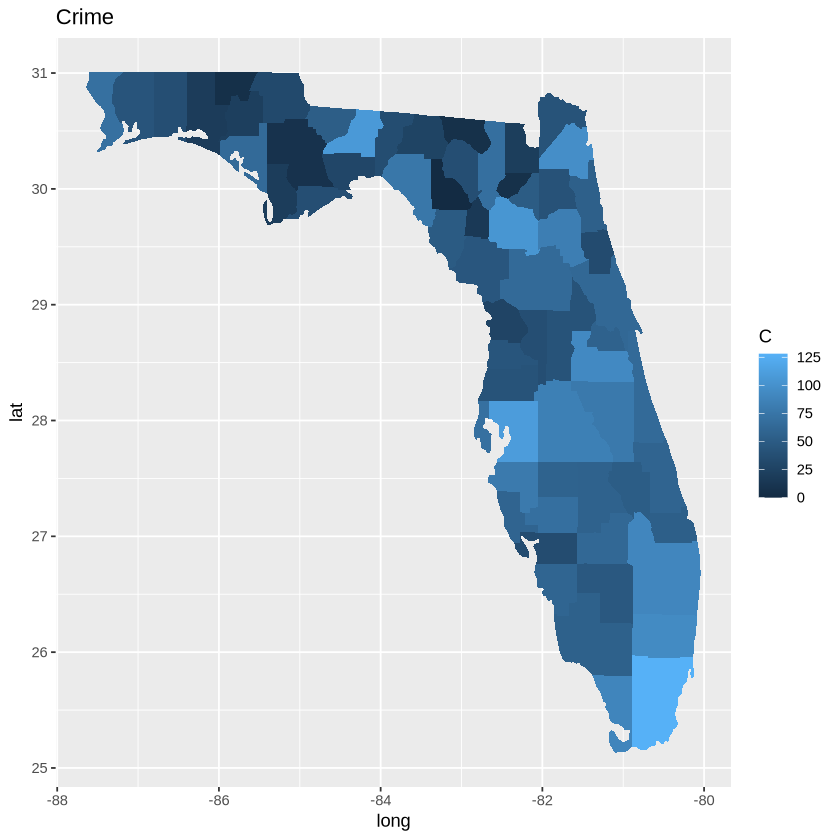

In [2]:
## Code for illustration purposes only
us_counties <- map_data("county")
florida_counties <- us_counties %>%
  filter(region == "florida")
crime_match <- crime %>%
  mutate(
    County = str_to_lower(str_replace_all(County, "\\.", ""))
  )
county_name_compat <- c(
  "washington" = "washing",
  "santa rosa" = "santar",
  "suwannee" = "suwanee",
  "palm beach" = "palmb",
  "okeechobee" = "okeech",
  "indian river" = "indianr",
  "hillsborough" = "hillsbor",
  "miami-dade" = "dade"
)
florida_crime <- florida_counties %>%
  mutate(
    County = dplyr::recode(subregion, !!!county_name_compat),
    County = str_replace_all(County, "\\s", "")
  ) %>%
  left_join(crime_match, by = "County")
p1 <- florida_crime %>%
  ggplot(aes(x = long, y = lat, group = group, fill = U)) +
  geom_polygon() +
  labs(
    title = "Urbanisation"
  )
p2 <- florida_crime %>%
  ggplot(aes(x = long, y = lat, group = group, fill = HS)) +
  geom_polygon() +
  labs(
    title = "Education"
  )
p3 <- florida_crime %>%
  ggplot(aes(x = long, y = lat, group = group, fill = C)) +
  geom_polygon() +
  labs(
    title = "Crime"
  )
p3


Variables description:

-   `C`: number of crimes per 100,000 inhabitants
-   `HS`: share of high school graduates
-   `U`: share of persons living in urban areas

## First model: crime and education

$$
\underbrace{C_i}_{\text{Crime in county i}} = \beta_0 + \beta_1 \underbrace{\text{HS}_i}_{\text{Share of persons with high school degree in county i}} + \underbrace{e_i}_{\text{Random term for county i}}, \quad i = 1,\ldots,n = 67
$$

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


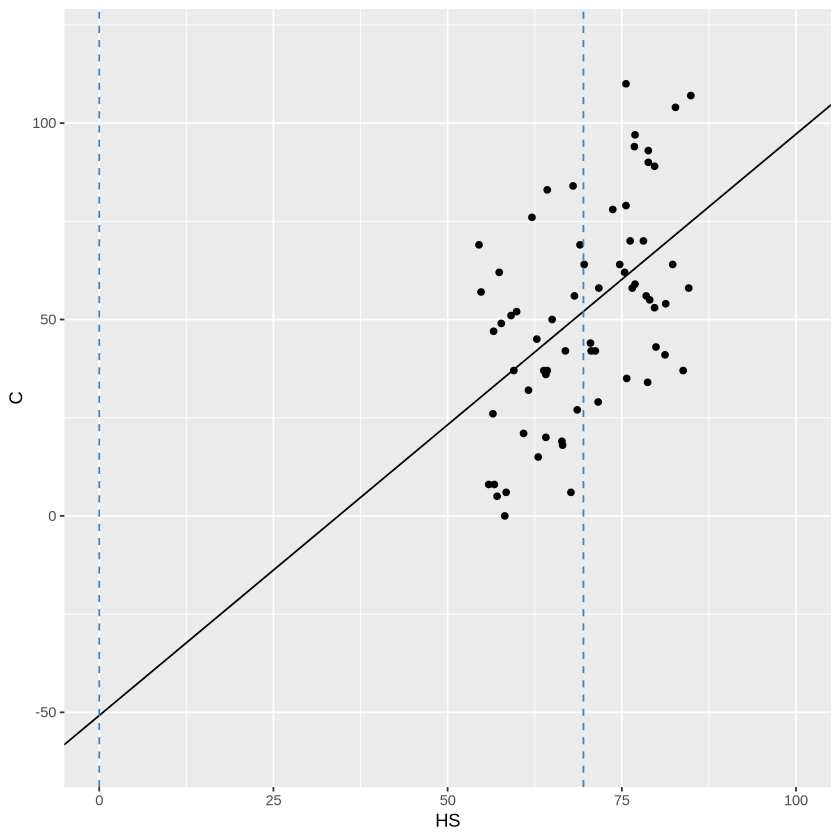

In [3]:
crime |>
  ggplot(aes(x = HS, y = C)) +
    geom_point() +
    xlim(c(0, 100)) +
    ylim(c(-60, 120)) +
    geom_abline(intercept = -50.8, slope = 1.48) +
    geom_vline(xintercept = c(0, mean(crime$HS)), color = "steelblue", lty = 2)

In [ ]:
# See the model matrix


In [ ]:
# Calculate the OLS estimates by hand using the matrix formula


(Intercept),-50.856902
HS,1.485977


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


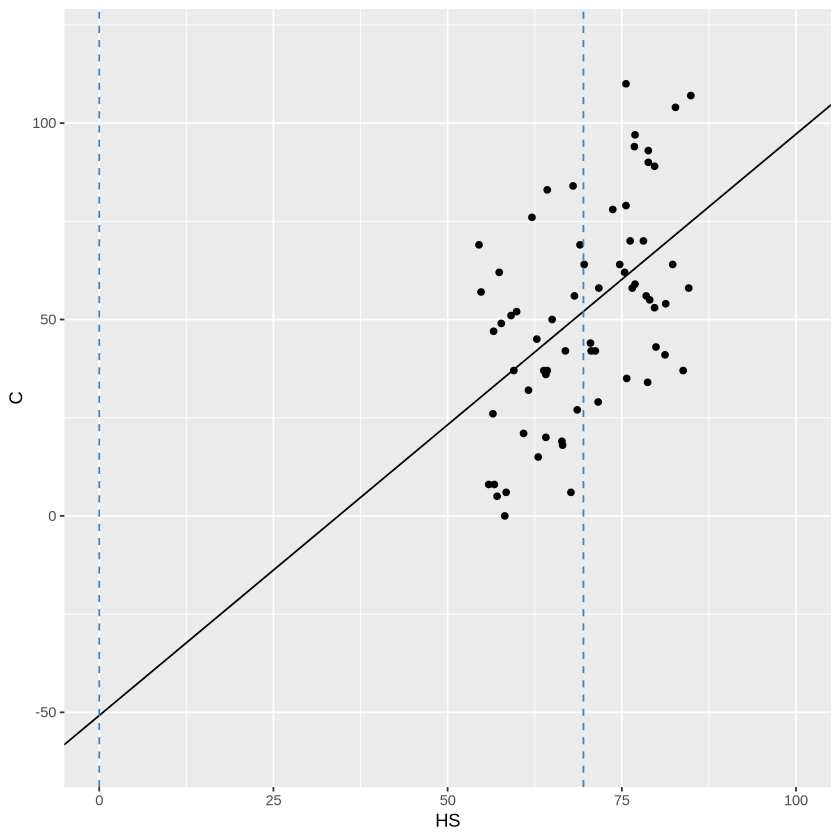

In [12]:
crime |>
  ggplot(aes(x = HS, y = C)) +
    geom_point() +
    xlim(c(0, 100)) +
    ylim(c(-60, 120)) +
    geom_abline(intercept = -50.8, slope = 1.48) +
    geom_vline(xintercept = c(0, mean(crime$HS)), color = "steelblue", lty = 2)

## Third Model: Education and Urbanization

$$
\text{HS}_i = \beta_0 + \beta_1 U_i + e_i
$$



In [6]:
# Fit the model and print the summary




## Graphical representation of the data



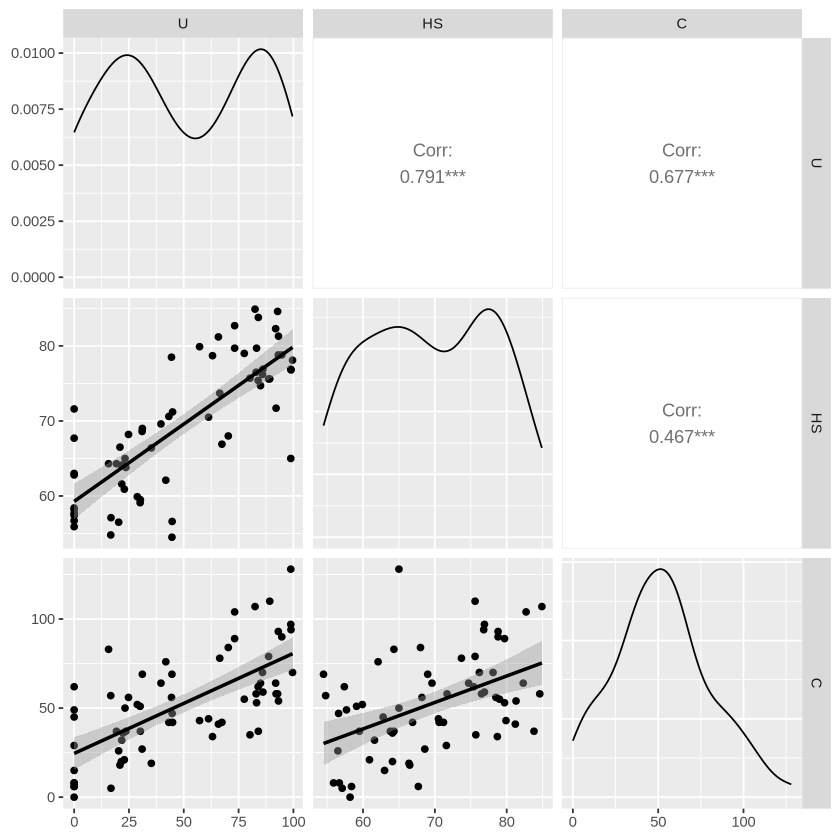

In [7]:
ggpairs(crime, columns = c(4, 3, 2), lower = list(continuous = "smooth"))


## Fourth Model: Crime, Education, and Urbanization

$$
C_i = \beta_0 + \beta_1 \text{HS}_i  + \beta_2 \text{U}_i + e_i
$$



## The curious case of Dr. Simpson


In [18]:
dt <- read_csv("https://github.com/febse/econ2026/raw/refs/heads/main/data/ggb.csv")

dt |> head()

Rows: 127 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): sex, drug
dbl (1): ha

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


sex,drug,ha
<chr>,<chr>,<dbl>
F,N,1
M,N,1
M,N,1
M,N,1
M,N,1
M,N,1
